In [2]:
pip install numpy pandas matplotlib scikit-learn

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.0.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.0 MB 5.3 MB/s eta 0:00:02
   ------ --------------------------------- 1.8/11.0 MB 4.7 MB/s eta 0:00:02
   --------- ------------------------------ 2.6/11.0 MB 4.7 MB/s eta 0:00:02
   ------------- -------------------------- 3.7/11.0 MB 4.6 MB/s eta 0:00:02
   ---------------- ----------------------- 4.5/11.0 MB 4.5 MB/s eta 0:00:02
   ------------------- -------------------- 5.2/11.0 MB 4.4 MB/s eta 0:00:02
   -------------------- ------------------- 5.8/11.0 MB 4.2 MB/s eta 0:00:02
   ----------------------- ---------------- 6.6/11.0 MB 4.0 MB/s eta 0:00:02
   -------------------------- ------------- 7.3/11.0 MB 3.9 MB/s eta 0:00:01
   ---------------------------- ----------- 7.9/11.0 MB 3.9 MB/s eta 0:00:01
   --------------------

In [21]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from IPython.display import display


In [22]:
X, y = load_breast_cancer(return_X_y=True)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

dev_fraction_of_temp = 0.15 / (1 - 0.15)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_temp, y_temp, test_size=dev_fraction_of_temp, random_state=42, stratify=y_temp
)

print(f"Sizes: train={X_train.shape[0]}, dev={X_dev.shape[0]}, test={X_test.shape[0]}")


Sizes: train=397, dev=86, test=86


In [24]:

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_dev_std = scaler.transform(X_dev)
X_test_std = scaler.transform(X_test)

print("Train mean (per feature) approx:", np.mean(X_train_std, axis=0)[:5])
print("Train std  (per feature) approx:", np.std(X_train_std, axis=0)[:5])


Train mean (per feature) approx: [-2.44528719e-15 -2.53925065e-16  3.63996546e-15  5.63780760e-16
 -4.20710206e-15]
Train std  (per feature) approx: [1. 1. 1. 1. 1.]


In [25]:
eta0_list = [0.001, 0.01, 0.1, 1.0]
max_iter_list = [5, 50, 200]
learning_histories = {}   
summary_rows = []
classes = np.unique(y_train)

def key_for(eta0, max_iter):
    eta_str = format(eta0, ".3g")   
    return f"eta0={eta_str}_maxiter={max_iter}"


In [26]:
for eta0 in eta0_list:
    for max_iter in max_iter_list:
        key = key_for(eta0, max_iter)
        print("Training:", key)
        clf = Perceptron(eta0=eta0, tol=None, shuffle=True, random_state=0)
        train_accs = []
        dev_accs = []
        t_updates = []

        try:
            for epoch in range(1, max_iter + 1):
                clf.partial_fit(X_train_std, y_train, classes=classes)
                train_accs.append(clf.score(X_train_std, y_train))
                dev_accs.append(clf.score(X_dev_std, y_dev))
                t_updates.append(getattr(clf, "t_", None))
        except Exception as e:
            print(f"  -> Error during training {key}: {e}")

        learning_histories[key] = {
            "train_accs": train_accs,
            "dev_accs": dev_accs,
            "t_updates": t_updates
        }

        summary_rows.append({
            "config": key,
            "eta0": eta0,
            "max_iter_param": max_iter,
            "n_epochs_recorded": len(train_accs),
            "t_updates_final": t_updates[-1] if t_updates else None,
            "train_acc_final": train_accs[-1] if train_accs else None,
            "dev_acc_final": dev_accs[-1] if dev_accs else None,
            "test_acc_final": clf.score(X_test_std, y_test) if hasattr(clf, "coef_") else None
        })

print("Training finished.")


Training: eta0=0.001_maxiter=5
Training: eta0=0.001_maxiter=50
Training: eta0=0.001_maxiter=200
Training: eta0=0.01_maxiter=5
Training: eta0=0.01_maxiter=50
Training: eta0=0.01_maxiter=200
Training: eta0=0.1_maxiter=5
Training: eta0=0.1_maxiter=50
Training: eta0=0.1_maxiter=200
Training: eta0=1_maxiter=5
Training: eta0=1_maxiter=50
Training: eta0=1_maxiter=200
Training finished.


In [27]:
print("\nSaved history keys (count={}):".format(len(learning_histories)))
for k in sorted(learning_histories.keys()):
    print(" ", k)

summary_df = pd.DataFrame(summary_rows).sort_values(["eta0", "max_iter_param"]).reset_index(drop=True)
display(summary_df)



Saved history keys (count=12):
  eta0=0.001_maxiter=200
  eta0=0.001_maxiter=5
  eta0=0.001_maxiter=50
  eta0=0.01_maxiter=200
  eta0=0.01_maxiter=5
  eta0=0.01_maxiter=50
  eta0=0.1_maxiter=200
  eta0=0.1_maxiter=5
  eta0=0.1_maxiter=50
  eta0=1_maxiter=200
  eta0=1_maxiter=5
  eta0=1_maxiter=50


,config,eta0,max_iter_param,n_epochs_recorded,t_updates_final,train_acc_final,dev_acc_final,test_acc_final
0,eta0=0.001_maxiter=5,0.001,5,5,1986.0,0.954660,0.988372,0.965116
1,eta0=0.001_maxiter=50,0.001,50,50,19851.0,0.979849,0.976744,0.941860
2,eta0=0.001_maxiter=200,0.001,200,200,79401.0,0.987406,0.953488,0.906977
3,eta0=0.01_maxiter=5,0.010,5,5,1986.0,0.954660,0.988372,0.965116
4,eta0=0.01_maxiter=50,0.010,50,50,19851.0,0.979849,0.976744,0.941860
5,eta0=0.01_maxiter=200,0.010,200,200,79401.0,0.987406,0.953488,0.906977
6,eta0=0.1_maxiter=5,0.100,5,5,1986.0,0.954660,0.988372,0.965116
7,eta0=0.1_maxiter=50,0.100,50,50,19851.0,0.979849,0.976744,0.941860
8,eta0=0.1_maxiter=200,0.100,200,200,79401.0,0.987406,0.953488,0.906977
9,eta0=1_maxiter=5,1.000,5,5,1986.0,0.954660,0.988372,0.965116


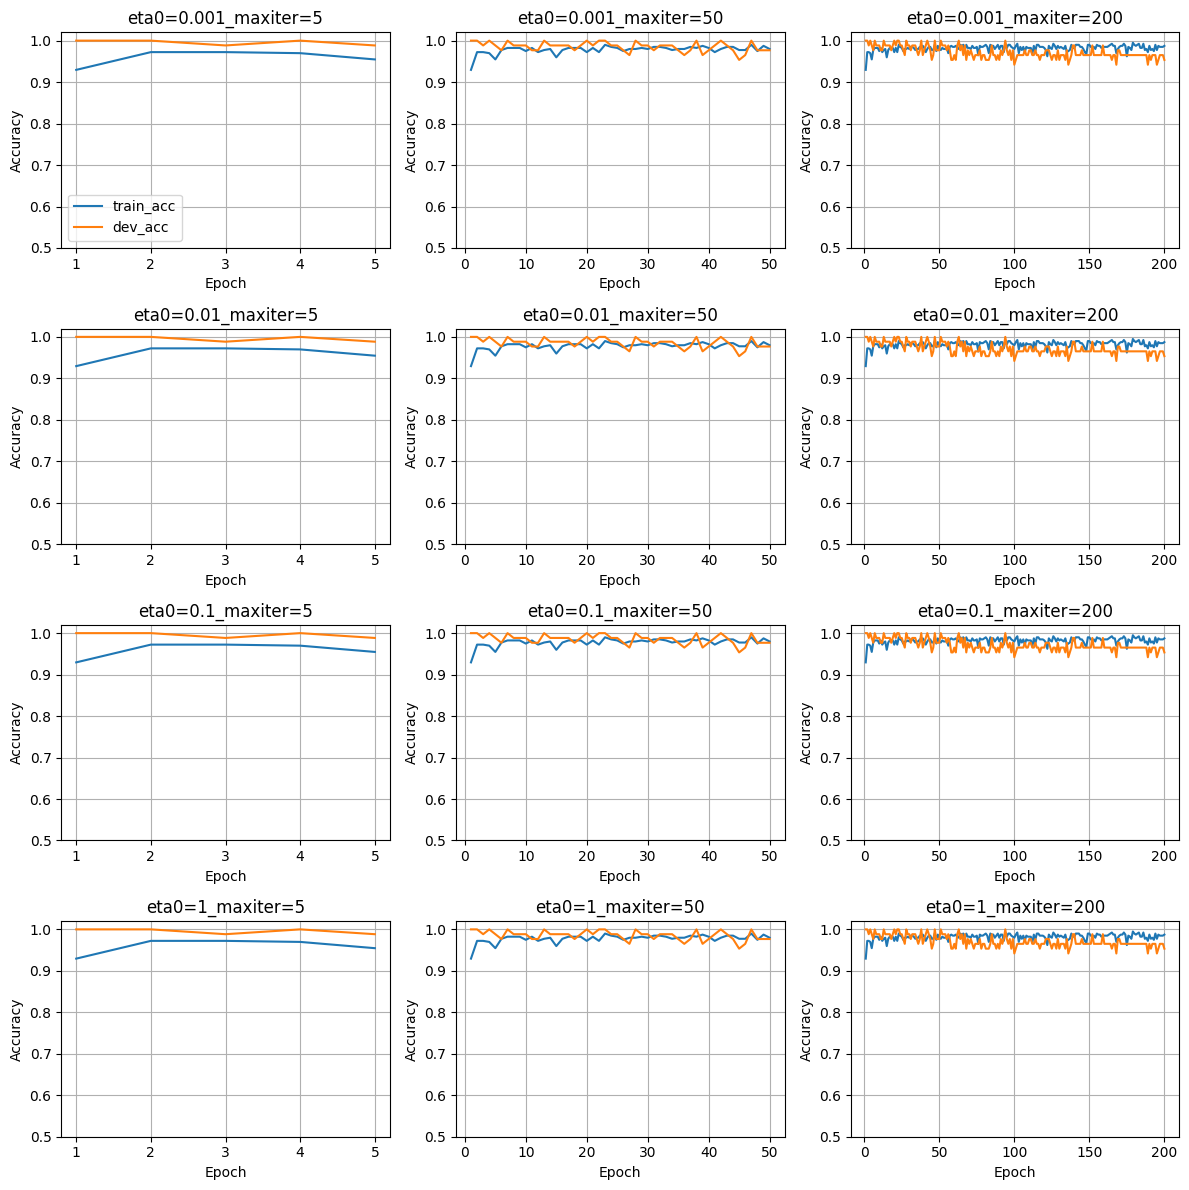

In [28]:
n_eta = len(eta0_list)
n_max = len(max_iter_list)
fig, axes = plt.subplots(n_eta, n_max, figsize=(4*n_max, 3*n_eta), squeeze=False)

for i, eta0 in enumerate(eta0_list):
    for j, max_iter in enumerate(max_iter_list):
        key = key_for(eta0, max_iter)
        ax = axes[i][j]
        ax.set_title(key)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.set_ylim(0.5, 1.02)
        ax.grid(True)

        if key not in learning_histories:
            ax.text(0.5, 0.5, f"No history for\n{key}", ha="center", va="center")
            ax.set_title(key + " (missing)")
            continue

        hist = learning_histories[key]
        train_accs = hist.get("train_accs", [])
        dev_accs = hist.get("dev_accs", [])

        if len(train_accs) == 0:
            ax.text(0.5, 0.5, f"Empty history\n{key}", ha="center", va="center")
            ax.set_title(key + " (empty)")
            continue

        epochs = np.arange(1, len(train_accs) + 1)
        ax.plot(epochs, train_accs, label="train_acc")
        ax.plot(epochs, dev_accs, label="dev_acc")
        if i == 0 and j == 0:
            ax.legend()

plt.tight_layout()
plt.show()


In [29]:
if len(summary_df) > 0 and summary_df["dev_acc_final"].notnull().any():
    best_idx = summary_df["dev_acc_final"].idxmax()
    best_row = summary_df.loc[best_idx]
    print("Best config by dev accuracy:")
    display(best_row)
else:
    print("No valid entries in summary_df to choose best from.")


Best config by dev accuracy:


config               eta0=0.001_maxiter=5
eta0                                0.001
max_iter_param                          5
n_epochs_recorded                       5
t_updates_final                    1986.0
train_acc_final                   0.95466
dev_acc_final                    0.988372
test_acc_final                   0.965116
Name: 0, dtype: object

In [30]:
best_idx = summary_df["dev_acc_final"].idxmax()
best_row = summary_df.loc[best_idx]

print("Best Hyperparameters:")
print("  eta0        =", best_row["eta0"])
print("  max_iter    =", best_row["max_iter_param"])

print("\nModel Accuracies:")
print("  Train Accuracy =", round(best_row["train_acc_final"], 4))
print("  Dev Accuracy   =", round(best_row["dev_acc_final"], 4))
print("  Test Accuracy  =", round(best_row["test_acc_final"], 4))


Best Hyperparameters:
  eta0        = 0.001
  max_iter    = 5

Model Accuracies:
  Train Accuracy = 0.9547
  Dev Accuracy   = 0.9884
  Test Accuracy  = 0.9651


In [31]:
summary_df[["config", "train_acc_final", "dev_acc_final", "test_acc_final"]]


,config,train_acc_final,dev_acc_final,test_acc_final
0,eta0=0.001_maxiter=5,0.954660,0.988372,0.965116
1,eta0=0.001_maxiter=50,0.979849,0.976744,0.941860
2,eta0=0.001_maxiter=200,0.987406,0.953488,0.906977
3,eta0=0.01_maxiter=5,0.954660,0.988372,0.965116
4,eta0=0.01_maxiter=50,0.979849,0.976744,0.941860
5,eta0=0.01_maxiter=200,0.987406,0.953488,0.906977
6,eta0=0.1_maxiter=5,0.954660,0.988372,0.965116
7,eta0=0.1_maxiter=50,0.979849,0.976744,0.941860
8,eta0=0.1_maxiter=200,0.987406,0.953488,0.906977
9,eta0=1_maxiter=5,0.954660,0.988372,0.965116
